In [2]:
#Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load the dataset
landmarks_and_places_df = pd.read_csv('landmarks-and-places-of-interest-including-schools-theatres-health-services-spor.csv')
art_places_df = pd.read_csv('public-artworks-fountains-and-monuments.csv')
#Check the dataset structure
print(landmarks_and_places_df.info())
print(landmarks_and_places_df.head())
print(art_places_df.info())
print(art_places_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Theme         242 non-null    str  
 1   Sub Theme     242 non-null    str  
 2   Feature Name  242 non-null    str  
 3   Co-ordinates  242 non-null    str  
dtypes: str(4)
memory usage: 7.7 KB
None
                Theme                                        Sub Theme  \
0  Leisure/Recreation               Major Sports & Recreation Facility   
1    Education Centre                                  Primary Schools   
2  Leisure/Recreation  Informal Outdoor Facility (Park/Garden/Reserve)   
3    Education Centre                                Secondary Schools   
4           Mixed Use                            Retail/Office/Carpark   

                          Feature Name                         Co-ordinates  
0                Carlton Football Club  -37.7840864379557, 144.961967841559  
1       Carlton Gar

In [4]:
# Check the unique theme and subtheme of the landmarks dataset
print(landmarks_and_places_df['Theme'].unique())
print(landmarks_and_places_df['Sub Theme'].unique())

# Check the duplicate entries in the landmarks dataset
print(landmarks_and_places_df.value_counts(subset=['Feature Name']) > 1)

# remove duplicates
landmarks_and_places_df1 = landmarks_and_places_df.drop_duplicates(subset=['Feature Name'])
print(landmarks_and_places_df1.value_counts(subset=['Feature Name']) > 1)


<StringArray>
[                  'Leisure/Recreation',
                     'Education Centre',
                            'Mixed Use',
                    'Place Of Assembly',
                               'Office',
                      'Health Services',
                            'Transport',
                     'Place of Worship',
                               'Retail',
                        'Community Use',
                        'Purpose Built',
                          'Vacant Land',
                      'Warehouse/Store',
                           'Industrial',
            'Residential Accommodation',
 'Specialist Residential Accommodation']
Length: 16, dtype: str
<StringArray>
[             'Major Sports & Recreation Facility',
                                 'Primary Schools',
 'Informal Outdoor Facility (Park/Garden/Reserve)',
                               'Secondary Schools',
                           'Retail/Office/Carpark',
                              'Ar

In [5]:
#Check the unique categories of the art places dataset
print(art_places_df['Asset Type'].unique())

#Check the repeated name in the art places dataset  
print(art_places_df['Name'].value_counts())

#Drop duplicates in the art places dataset based on 'Name' and 'Mel way Ref' columns
art_places_df1 = art_places_df.drop_duplicates(subset=['Name', 'Mel way Ref'])
print(art_places_df1.info())

<StringArray>
['Art', 'Monument', 'Fountain']
Length: 3, dtype: str
Name
Scar - A Stolen Vision                            27
Federation Bells                                  13
Silence                                           13
Blowhole                                           8
Threaded Field                                     7
                                                  ..
Photo art billboard                                1
Railway Viewing Platform                           1
R.J. & F.G.J. Hardy Memorial Drinking Fountain     1
Adam Lindsay Gordan Memorial                       1
Angel                                              1
Name: count, Length: 163, dtype: int64
<class 'pandas.DataFrame'>
Index: 164 entries, 0 to 260
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Asset Type         164 non-null    str    
 1   Name               164 non-null    str    
 2   Xorg               

From check the repeat we can find that there are some repeat art design in art_place dataset.

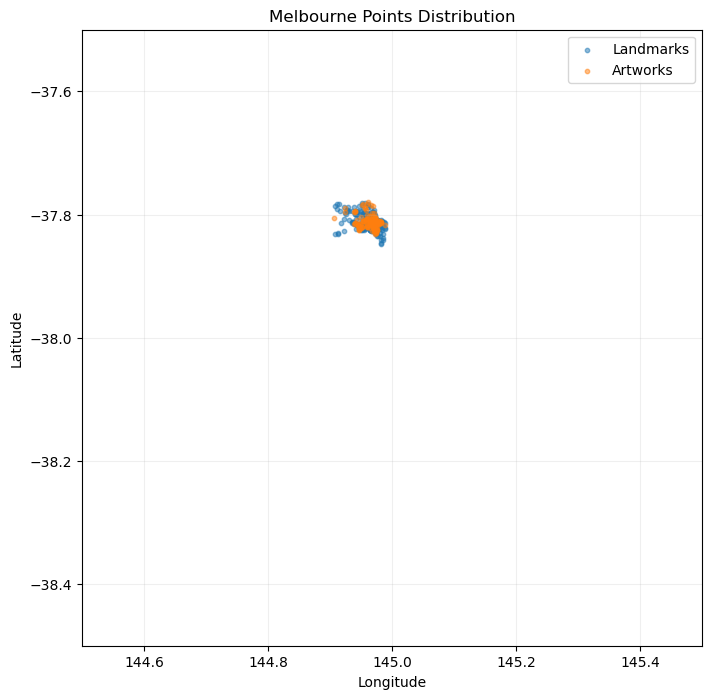

Landmarks valid: 233
Artworks valid: 164


In [6]:
# Check the distribution of coordinates in two datasets, visualize them on a scatter plot to identify any outliers or clustering patterns.
# Melbourne bounding box
MELB_LON_MIN, MELB_LON_MAX = 144.5, 145.5
MELB_LAT_MIN, MELB_LAT_MAX = -38.5, -37.5


# Use coordinates parsing function to extract lat/lon from the "Co-ordinates" column
def parse_coordinates(df):
    d = df.copy()
    d.columns = [c.strip() for c in d.columns]

    parts = d["Co-ordinates"].astype(str).str.split(",", n=1, expand=True)

    lat = pd.to_numeric(parts[0].str.strip(), errors="coerce")
    lon = pd.to_numeric(parts[1].str.strip(), errors="coerce")

    return lat, lon


# Validation function to check if lat/lon are within Melbourne bounds
def get_valid_mask(lat, lon):
    melb_ok = lat.between(MELB_LAT_MIN, MELB_LAT_MAX) & lon.between(MELB_LON_MIN, MELB_LON_MAX)
    return melb_ok


# Parse coordinates and get valid masks for both datasets
lm_lat, lm_lon = parse_coordinates(landmarks_and_places_df1)
aw_lat, aw_lon = parse_coordinates(art_places_df1)

lm_valid = get_valid_mask(lm_lat, lm_lon)
aw_valid = get_valid_mask(aw_lat, aw_lon)


# Visualization
plt.figure(figsize=(8, 8))

plt.scatter(lm_lon[lm_valid], lm_lat[lm_valid], s=10, alpha=0.5, label="Landmarks")
plt.scatter(aw_lon[aw_valid], aw_lat[aw_valid], s=10, alpha=0.5, label="Artworks")

plt.xlim(MELB_LON_MIN, MELB_LON_MAX)
plt.ylim(MELB_LAT_MIN, MELB_LAT_MAX)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Melbourne Points Distribution")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


# Print the number of valid coordinates in each dataset
print("Landmarks valid:", lm_valid.sum())
print("Artworks valid:", aw_valid.sum())



In [7]:
# Create a series map to fit the database schema
series_id_map = {
    "Nature": 1,
    "Urban": 2,
    "Art": 3,
}

# For landmarks, keep only the proper theme for children and match the series in database
subtheme_mapping = {
    # Natual
    "Informal Outdoor Facility (Park/Garden/Reserve)": "Nature",
    "Outdoor Recreation Facility (Zoo, Golf Course)": "Nature",
    "Marina": "Nature",
    "Aquarium": "Nature",  

    # Urban
    "Railway Station": "Urban",
    "Transport Terminal": "Urban",
    "Bridge": "Urban",
    "Observation Tower/Wheel": "Urban",
    "Public Buildings": "Urban",
    "Library": "Urban",
    "Major Sports & Recreation Facility": "Urban",
    "Function/Conference/Exhibition Centre": "Urban",

    # Art 
    "Art Gallery/Museum": "Art",
    "Theatre Live": "Art",
    "Visitor Centre": "Art",
    "Sculpture": "Art",
    "Fountain": "Art",
    "Monument": "Art",
    "Mural": "Art",
    "Artwork": "Art",
    "Memorial": "Art",
    "Installation": "Art",
}

# For artworks dataset, map all to "Art"
art_places_df1["series_id"] = 3

In [14]:
# Keep only the subthemes that are in the mapping and create a series_id column for landmarks dataset
landmarks_and_places_df1["series_id"] = landmarks_and_places_df1["Sub Theme"].map(subtheme_mapping)
# drop rows with NaN series_id
landmarks_and_places_df1 = landmarks_and_places_df1.dropna(subset=["series_id"])
# Change the series_id to numeric using the series_id_map
landmarks_and_places_df1["series_id"] = landmarks_and_places_df1["series_id"].map(series_id_map)

# Create a function to split the Co-ordinates into lat and lon columns
def split_coordinates(df):
    coords = df["Co-ordinates"].str.split(",", expand=True)
    df["latitude"] = pd.to_numeric(coords[0].str.strip(), errors="coerce")
    df["longitude"] = pd.to_numeric(coords[1].str.strip(), errors="coerce")
    return df

# Apply the function to both datasets
landmarks_and_places_df1 = split_coordinates(landmarks_and_places_df1)
art_places_df1 = split_coordinates(art_places_df1)

# Extract suburb from Address Point as location_label for artworks dataset
art_places_df1["location_label"] = art_places_df1["Address Point"].str.split(",").str[1].str.strip()


print(landmarks_and_places_df1.head())
print(art_places_df1.head())

                Theme                                        Sub Theme  \
0  Leisure/Recreation               Major Sports & Recreation Facility   
2  Leisure/Recreation  Informal Outdoor Facility (Park/Garden/Reserve)   
5   Place Of Assembly                               Art Gallery/Museum   
7  Leisure/Recreation  Informal Outdoor Facility (Park/Garden/Reserve)   
9           Transport                                  Railway Station   

                             Feature Name  \
0                   Carlton Football Club   
2                            Kings Domain   
5  Australian Centre for Contemporary Art   
7                       Federation Square   
9        South Kensington Railway Station   

                          Co-ordinates  series_id   latitude   longitude  
0  -37.7840864379557, 144.961967841559          2 -37.784086  144.961968  
2  -37.8255239795833, 144.974107925144          1 -37.825524  144.974108  
5  -37.8266045432686, 144.967252924593          3 -37.82660

In [22]:
# Change two datasets to fit the task table schema
# task_description / evaluation_criteria first use the same value as task_name, can be updated later if needed
# environment_type: outdoor
# location_label for artworks dataset can use the suburb extracted from address
# for landmarks dataset can be left as None for now (can be updated later if needed)
# first set base_difficulty=1, reward_point=10
# first set geofence_radius_meter=50

# Create task dataframes for landmarks and artworks datasets
landmarks_task = pd.DataFrame({
    "series_id": landmarks_and_places_df1["series_id"],
    "task_name": landmarks_and_places_df1["Feature Name"],
    "task_description": landmarks_and_places_df1["Feature Name"],
    "evaluation_criteria": landmarks_and_places_df1["Feature Name"],
    "environment_type": "outdoor",
    "task_type": 'photo',
    "location_label": None,  # first set as None, can be updated later if needed
    "latitude": pd.to_numeric(landmarks_and_places_df1["latitude"], errors="coerce"),
    "longitude": pd.to_numeric(landmarks_and_places_df1["longitude"], errors="coerce"),
    "st_point": None,  # first set as None, generate WKT POINT later based on latitude/longitude
    "geofence_radius_meter": 50,
    "base_difficulty": 1,
    "reward_point": 10,
    "is_active": 1
})

artworks_task = pd.DataFrame({
    "series_id": art_places_df1["series_id"],
    "task_name": art_places_df1["Name"],
    "task_description": art_places_df1["Name"],
    "evaluation_criteria": art_places_df1["Name"],
    "environment_type": "outdoor",
    "task_type": 'photo',
    "location_label": art_places_df1["location_label"],
    "latitude": pd.to_numeric(art_places_df1["latitude"], errors="coerce"),
    "longitude": pd.to_numeric(art_places_df1["longitude"], errors="coerce"),
    "st_point": None,  # first set as None, generate WKT POINT later based on latitude/longitude
    "geofence_radius_meter": 50,
    "base_difficulty": 1,
    "reward_point": 10,
    "is_active": 1
})

# Combine the two datasets and do final cleaning before export
task_seed_df = pd.concat([landmarks_task, artworks_task], ignore_index=True)

task_seed_df = task_seed_df.dropna(subset=["series_id", "task_name", "latitude", "longitude"])
task_seed_df = task_seed_df[
    task_seed_df["latitude"].between(MELB_LAT_MIN, MELB_LAT_MAX) &
    task_seed_df["longitude"].between(MELB_LON_MIN, MELB_LON_MAX)
].copy()

# create st_point column in WKT format for MySQL (POINT(lon lat))
task_seed_df["st_point"] = task_seed_df.apply(
    lambda r: f"POINT({r['longitude']} {r['latitude']})", axis=1
)

# make sure series_id is int for database import
task_seed_df["series_id"] = task_seed_df["series_id"].astype(int)

# reorder columns to fit the database schema
task_seed_df = task_seed_df[
    [
        "series_id", "task_name", "task_description", "evaluation_criteria",
        "environment_type", "task_type", "location_label", "latitude", "longitude",
        "st_point", "geofence_radius_meter", "base_difficulty", "reward_point", "is_active"
    ]
]

print(task_seed_df.head())
print(f"Total rows ready for import: {len(task_seed_df)}")

# Export the final task seed data to CSV for database import
task_seed_df.to_csv("task_seed_outdoor.csv", index=False, encoding="utf-8-sig")
print("Exported: task_seed_outdoor.csv")

   series_id                               task_name  \
0          2                   Carlton Football Club   
1          1                            Kings Domain   
2          3  Australian Centre for Contemporary Art   
3          1                       Federation Square   
4          2        South Kensington Railway Station   

                         task_description  \
0                   Carlton Football Club   
1                            Kings Domain   
2  Australian Centre for Contemporary Art   
3                       Federation Square   
4        South Kensington Railway Station   

                      evaluation_criteria environment_type task_type  \
0                   Carlton Football Club          outdoor     photo   
1                            Kings Domain          outdoor     photo   
2  Australian Centre for Contemporary Art          outdoor     photo   
3                       Federation Square          outdoor     photo   
4        South Kensington Railwa